# DEEPL – TP 1 : Définition de fonctions en PyTorch

Etudiant : Félix Bos

1. **Partie théorique** (Q1 → Q5) : dérivation chaînée, gradients de la MSE et de la fonction linéaire (scalaire, puis matriciel).
2. **Implémentation** (Q6) : classes `MSE` et `Linear` héritant de `torch.autograd.Function`, vérification avec `gradcheck`.
3. **Descente de gradient** (Q7) : descente « à la main » (`tp1_descente.py`), puis avec autograd sur *California Housing*, et comparaison batch / mini‑batch / stochastique.

## 2. Fonction dans un graphe

### Question 1

Soit $h:\mathbb{R}^n\to\mathbb{R}^p$, $\mathbf{y}=h(\mathbf{x})$ et $L:\mathbb{R}^p\to\mathbb{R}$. Chaque sortie $y_j$ dépend de $x_i$, donc par dérivation des fonctions composées :

$$
\frac{\partial (L\circ h)}{\partial x_i}(\mathbf{x})
= \sum_{j=1}^{p} \frac{\partial L}{\partial y_j}(h(\mathbf{x}))\,\frac{\partial h_j}{\partial x_i}(\mathbf{x})
= \sum_{j=1}^{p} (\nabla L)_j\,\frac{\partial h_j}{\partial x_i}(\mathbf{x})
$$

Sous forme vectorielle, avec $J_h(\mathbf{x})\in\mathbb{R}^{p\times n}$ la jacobienne de $h$ ($[J_h]_{ji}=\partial h_j/\partial x_i$) :

$$
\nabla_{\mathbf{x}}(L\circ h) = J_h(\mathbf{x})^\top\,\nabla L
$$

C'est exactement ce que calcule la passe **backward** : elle reçoit $\nabla L$ (le gradient qui arrive d'en haut ) et renvoie un produit *vecteur‑jacobienne*.

## 3. Application : régression linéaire

### Question 2 (cas scalaire)

On note $\delta = L'(\text{mse}(\hat y, y))$ le gradient reçu de l'aval (si la MSE est la dernière opération, $L=\text{id}$ et $\delta=1$).

**MSE** : $\text{mse}(\hat y, y) = (\hat y - y)^2$

$$
\frac{\partial L\circ \text{mse}}{\partial \hat y}(\hat y, y) = 2\,\delta\,(\hat y - y)
\qquad
\frac{\partial L\circ \text{mse}}{\partial y}(\hat y, y) = -2\,\delta\,(\hat y - y)
$$

**Linéaire** : $f(\mathbf{x},\mathbf{w},b)=\mathbf{x}\cdot\mathbf{w}+b = \sum_k x_k w_k + b$, avec $\delta = L'(f(\mathbf{x},\mathbf{w},b))$ (ici $L=\text{mse}(\cdot, y)$, donc $\delta = 2(\hat y - y)$) :

$$
\frac{\partial L\circ f}{\partial x_j} = \delta\, w_j
\qquad
\frac{\partial L\circ f}{\partial w_j} = \delta\, x_j
\qquad
\frac{\partial L\circ f}{\partial b} = \delta
$$

### Question 3 (cas matriciel, composante par composante)

Dimensions : $\mathbf{X}\in\mathbb{R}^{q\times n}$, $\mathbf{W}\in\mathbb{R}^{n\times p}$, $\mathbf{b}\in\mathbb{R}^{1\times p}$, $\hat{\mathbf{Y}},\mathbf{Y}\in\mathbb{R}^{q\times p}$.

**MSE** : $\text{mse}(\hat{\mathbf{Y}},\mathbf{Y}) = \frac1q\sum_{k,l}(\hat Y_{kl}-Y_{kl})^2$. La sortie est un scalaire ; on note $\delta$ le gradient scalaire reçu. Seul le terme $(k,l)=(i,j)$ dépend de $\hat Y_{ij}$ :

$$
\frac{\partial L\circ \text{mse}}{\partial \hat Y_{ij}} = \frac{2\delta}{q}\,(\hat Y_{ij}-Y_{ij})
\qquad
\frac{\partial L\circ \text{mse}}{\partial Y_{ij}} = -\frac{2\delta}{q}\,(\hat Y_{ij}-Y_{ij})
$$

**Linéaire** : $\hat Y_{kl} = \sum_m X_{km}W_{ml} + b_l$. On note $G_{kl} = \frac{\partial L}{\partial \hat Y_{kl}}$ le gradient reçu (matrice $q\times p$). D'après la Q1, $\frac{\partial L\circ f}{\partial t} = \sum_{k,l} G_{kl}\,\frac{\partial \hat Y_{kl}}{\partial t}$, avec

- $\dfrac{\partial \hat Y_{kl}}{\partial X_{ij}} = \mathbb{1}[k=i]\,W_{jl}$
- $\dfrac{\partial \hat Y_{kl}}{\partial W_{ij}} = \mathbb{1}[l=j]\,X_{ki}$
- $\dfrac{\partial \hat Y_{kl}}{\partial b_{i}} = \mathbb{1}[l=i]$

d'où

$$
\frac{\partial L\circ f}{\partial X_{ij}} = \sum_{l=1}^{p} G_{il}\,W_{jl}
\qquad
\frac{\partial L\circ f}{\partial W_{ij}} = \sum_{k=1}^{q} X_{ki}\,G_{kj}
\qquad
\frac{\partial L\circ f}{\partial b_{i}} = \sum_{k=1}^{q} G_{ki}
$$

### Question 4 (écriture matricielle)

**MSE** :

$$
\frac{\partial L\circ \text{mse}}{\partial \hat{\mathbf{Y}}} = \frac{2\delta}{q}\,(\hat{\mathbf{Y}}-\mathbf{Y})
\qquad
\frac{\partial L\circ \text{mse}}{\partial \mathbf{Y}} = -\frac{2\delta}{q}\,(\hat{\mathbf{Y}}-\mathbf{Y})
$$

**Linéaire**, avec $\mathbf{G} = \frac{\partial L}{\partial \hat{\mathbf{Y}}}\in\mathbb{R}^{q\times p}$ et $\mathbf{1}_q\in\mathbb{R}^{q}$ le vecteur de uns :

$$
\frac{\partial L\circ f}{\partial \mathbf{X}} = \mathbf{G}\,\mathbf{W}^\top \;\;(q\times n)
\qquad
\frac{\partial L\circ f}{\partial \mathbf{W}} = \mathbf{X}^\top\mathbf{G} \;\;(n\times p)
\qquad
\frac{\partial L\circ f}{\partial \mathbf{b}} = \mathbf{1}_q^\top\,\mathbf{G} \;\;(1\times p)
$$

(le gradient du biais est la somme des lignes de $\mathbf{G}$ : c'est le « transposé » du broadcast du forward). On vérifie que chaque gradient a la même forme que la variable correspondante.

### Question 5 (gradient de $C$)

$C(\mathbf{X},\mathbf{W},\mathbf{b},\mathbf{Y}) = \text{mse}_{\mathbf{Y}}(f(\mathbf{X},\mathbf{W},\mathbf{b}))$. La MSE est la dernière opération ($\delta=1$), donc le gradient reçu par la fonction linéaire est

$$
\mathbf{G} = \frac{\partial\, \text{mse}_{\mathbf{Y}}}{\partial \hat{\mathbf{Y}}}(\hat{\mathbf{Y}}) = \frac{2}{q}(\hat{\mathbf{Y}}-\mathbf{Y}),
\qquad \hat{\mathbf{Y}} = \mathbf{X}\mathbf{W}+\mathbf{1}_q\mathbf{b}
$$

puis, par la Q4 :

$$
\boxed{\frac{\partial C}{\partial \mathbf{W}} = \frac{2}{q}\,\mathbf{X}^\top\big(\mathbf{X}\mathbf{W}+\mathbf{1}_q\mathbf{b}-\mathbf{Y}\big)}
\qquad
\boxed{\frac{\partial C}{\partial \mathbf{b}} = \frac{2}{q}\,\mathbf{1}_q^\top\big(\mathbf{X}\mathbf{W}+\mathbf{1}_q\mathbf{b}-\mathbf{Y}\big)}
$$

## 3 bis — Régression linéaire classique avec les notations $(n, p, b)$

Même calcul que les Q3–Q5, dans le cas classique : **une seule prédiction par individu**.

| symbole | signification | California Housing |
|---|---|---|
| $n$ | nombre d'individus (lignes) du jeu de données | $n = 16\,512$ (train) |
| $p$ | nombre de colonnes (features) | $p = 8$ |
| $b$ | nombre d'individus dans un batch | $b=n$ (batch), $b=32$ (mini‑batch), $b=1$ (SGD) |
| $\beta$ | biais : **un scalaire** (on ne peut plus l'appeler $b$) | |

On tire un batch de $b$ individus :

- $\mathbf{X}\in\mathbb{R}^{b\times p}$ : une ligne par individu, une colonne par feature
- $\mathbf{w}\in\mathbb{R}^{p}$ (vecteur colonne $p\times 1$) : un poids par feature
- $\beta\in\mathbb{R}$ : le biais
- $\hat{\mathbf{y}},\mathbf{y}\in\mathbb{R}^{b}$ (vecteurs colonnes $b\times 1$) : une prédiction / une cible par individu

**Forward** :

$$
\underbrace{\begin{pmatrix} \hat y_1 \\ \vdots \\ \hat y_b \end{pmatrix}}_{\hat{\mathbf{y}}\;(b\times 1)}
=
\underbrace{\begin{pmatrix} x_{11} & \cdots & x_{1p} \\ \vdots & & \vdots \\ x_{b1} & \cdots & x_{bp} \end{pmatrix}}_{\mathbf{X}\;(b\times p)}
\underbrace{\begin{pmatrix} w_1 \\ \vdots \\ w_p \end{pmatrix}}_{\mathbf{w}\;(p\times 1)}
+
\underbrace{\begin{pmatrix} \beta \\ \vdots \\ \beta \end{pmatrix}}_{\beta\,\mathbf{1}_b}
\qquad\Longleftrightarrow\qquad
\hat y_i = \sum_{j=1}^{p} x_{ij}w_j + \beta
$$

Le même $\beta$ est ajouté à chaque individu ($\mathbf{1}_b$ = vecteur de $b$ uns ; en PyTorch c'est le *broadcast* de `X @ w + beta`).

$$
\text{mse}(\hat{\mathbf{y}},\mathbf{y}) = \frac1b\sum_{i=1}^{b}(\hat y_i-y_i)^2 = \frac1b\|\hat{\mathbf{y}}-\mathbf{y}\|^2
$$

On divise par $b$ : c'est la moyenne sur le batch.

### Question 3 bis (composante par composante)

**MSE** : seul le terme $i$ de la somme dépend de $\hat y_i$ :

$$
\frac{\partial\, \text{mse}}{\partial \hat y_i} = \frac{2}{b}\,(\hat y_i-y_i)
\qquad
\frac{\partial\, \text{mse}}{\partial y_i} = -\frac{2}{b}\,(\hat y_i-y_i)
$$

On note $g_i = \dfrac{\partial L}{\partial \hat y_i}$ le gradient reçu par la fonction linéaire pour l'individu $i$. On a donc $\mathbf{g}\in\mathbb{R}^{b}$, et si $L = \text{mse}$ alors $g_i = \frac{2}{b}(\hat y_i - y_i)$ : c'est l'erreur de l'individu $i$ multipliée par $2/b$.

**Linéaire** : $\hat y_k = \sum_j x_{kj}w_j + \beta$. Par la Q1 : $\dfrac{\partial L\circ f}{\partial t} = \displaystyle\sum_{k=1}^{b} g_k\,\frac{\partial \hat y_k}{\partial t}$, avec

- $\dfrac{\partial \hat y_k}{\partial w_j} = x_{kj}$ : le poids $w_j$ intervient dans la prédiction de **tous** les individus
- $\dfrac{\partial \hat y_k}{\partial \beta} = 1$ : pareil pour le biais
- $\dfrac{\partial \hat y_k}{\partial x_{ij}} = \mathbb{1}[k=i]\;w_j$ : l'individu $i$ n'influence que sa propre prédiction

d'où

$$
\frac{\partial L\circ f}{\partial w_j} = \sum_{i=1}^{b} g_i\,x_{ij}
\qquad
\frac{\partial L\circ f}{\partial \beta} = \sum_{i=1}^{b} g_i
\qquad
\frac{\partial L\circ f}{\partial x_{ij}} = g_i\,w_j
$$

Les gradients des paramètres sont des **sommes sur les $b$ individus du batch** : chaque individu apporte sa contribution (son erreur $g_i$ multipliée par ses features $x_{ij}$).

### Question 4 bis (écriture matricielle)

$$
\frac{\partial\, \text{mse}}{\partial \hat{\mathbf{y}}} = \frac{2}{b}\,(\hat{\mathbf{y}}-\mathbf{y})
\qquad
\frac{\partial\, \text{mse}}{\partial \mathbf{y}} = -\frac{2}{b}\,(\hat{\mathbf{y}}-\mathbf{y})
\qquad (b\times 1)
$$

$$
\underbrace{\frac{\partial L\circ f}{\partial \mathbf{w}} = \mathbf{X}^\top\mathbf{g}}_{(p\times b)(b\times 1)\,=\,p\times 1}
\qquad
\underbrace{\frac{\partial L\circ f}{\partial \beta} = \mathbf{1}_b^\top\mathbf{g} = \sum_i g_i}_{\text{scalaire}}
\qquad
\underbrace{\frac{\partial L\circ f}{\partial \mathbf{X}} = \mathbf{g}\,\mathbf{w}^\top}_{(b\times 1)(1\times p)\,=\,b\times p}
$$

Astuce pour retrouver ces formules : chaque gradient a **la même forme que sa variable**. Pour obtenir un vecteur $p\times 1$ (comme $\mathbf{w}$) à partir de $\mathbf{X}$ ($b\times p$) et de $\mathbf{g}$ ($b\times 1$), la seule possibilité est $\mathbf{X}^\top\mathbf{g}$.

En PyTorch : `grad_w = X.T @ g`, `grad_beta = g.sum()`, `grad_X = g @ w.T`.

### Question 5 bis (gradient de $C$ sur un batch)

$$
\mathbf{g} = \frac{2}{b}\big(\mathbf{X}\mathbf{w}+\beta\mathbf{1}_b-\mathbf{y}\big)\in\mathbb{R}^{b}
\quad\text{(le vecteur des erreurs du batch} \times 2/b\text{)}
$$

$$
\boxed{\frac{\partial C}{\partial \mathbf{w}} = \frac{2}{b}\,\mathbf{X}^\top\big(\mathbf{X}\mathbf{w}+\beta\mathbf{1}_b-\mathbf{y}\big)}
\qquad
\boxed{\frac{\partial C}{\partial \beta} = \frac{2}{b}\sum_{i=1}^{b}\big(\hat y_i-y_i\big)}
$$

Les trois variantes de la Q7 correspondent au choix de $b$ :

- **batch** ($b=n$) : $\mathbf{X}$ est toute la matrice $n\times p$. On obtient le gradient exact.
- **mini‑batch** ($1<b<n$) : c'est une estimation du gradient complet, d'autant moins bruitée que $b$ est grand.
- **stochastique** ($b=1$) : un seul individu $\mathbf{x}_i$ (ligne de taille $1\times p$), et
$$\frac{\partial C}{\partial \mathbf{w}} = 2\,(\hat y_i - y_i)\,\mathbf{x}_i^\top \qquad \frac{\partial C}{\partial \beta} = 2\,(\hat y_i - y_i)$$
La mise à jour est proportionnelle à $\mathbf{x}_i$, d'où la condition $\epsilon < 1/\|\mathbf{x}_i\|^2$ vue en Q7.4.

**Lien avec le code** : dans le TP général (Q3–Q5), on autorise plusieurs sorties par individu. $\mathbf{W}$ est alors une matrice (une colonne par sortie) et le biais un vecteur (un biais par sortie). Avec une seule sortie, $\mathbf{W}$ redevient le vecteur $\mathbf{w}$ et le biais redevient le scalaire $\beta$. Dans le code California Housing, `W` est de taille $(8, 1)$ et `b` de taille $(1,)$ : c'est exactement $\mathbf{w}$ et $\beta$.

## 4. Implémentation des fonctions

### Question 6.1 — `MSE` et `Linear`

**Pourquoi autant de `grad_outputs` que de sorties du `forward` ?** Chaque sortie du forward est utilisée en aval et reçoit donc son propre gradient $\partial L/\partial \text{sortie}$. Le backward en a besoin pour appliquer la Q1 (somme sur toutes les sorties). Symétriquement, il renvoie **un gradient par entrée** du forward (ou `None` si l'entrée ne nécessite pas de gradient).

In [1]:
import time
import torch
from torch.autograd import Function, gradcheck
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

torch.manual_seed(0)

In [2]:
# Notations (cf. partie 3 bis) :
#   b = nombre d'individus dans le batch
#   p = nombre de colonnes (features)
#   d = nombre de sorties par individu  (d = 1 pour une régression linéaire classique)
#   beta = biais (un par sortie)

class Context:
    """Un objet contexte très simplifié pour simuler PyTorch

    Un contexte différent doit être utilisé à chaque forward
    """
    def __init__(self):
        self._saved_tensors = ()
    def save_for_backward(self, *args):
        self._saved_tensors = args
    @property
    def saved_tensors(self):
        return self._saved_tensors


class MSE(Function):
    """mse(yhat, y) = 1/b * ||yhat - y||^2   avec yhat, y de taille (b, d)"""
    @staticmethod
    def forward(ctx, yhat, y):
        ## Garde les valeurs nécessaires pour le backward
        ctx.save_for_backward(yhat, y)
        b = yhat.shape[0]
        return ((yhat - y) ** 2).sum() / b                  # scalaire

    @staticmethod
    def backward(ctx, grad_output):
        ## Calcul du gradient du module par rapport a chaque groupe d'entrées
        ## grad_output = dL/dmse (scalaire), vaut 1 si la MSE est la dernière couche
        yhat, y = ctx.saved_tensors
        b = yhat.shape[0]
        grad_yhat = grad_output * 2 * (yhat - y) / b        # (b, d)
        return grad_yhat, -grad_yhat                        # (b, d), (b, d)


class Linear(Function):
    """linear(X, W, beta) = X @ W + beta

    X    : (b, p)   un individu par ligne
    W    : (p, d)   une colonne de poids par sortie
    beta : (d,)     un biais par sortie (recopié sur les b lignes par broadcast)
    sortie yhat : (b, d)   -> avec d = 1 : une prédiction par individu
    """
    @staticmethod
    def forward(ctx, X, W, beta):
        ctx.save_for_backward(X, W, beta)
        return X @ W + beta                                 # (b, d)

    @staticmethod
    def backward(ctx, grad_output):
        ## grad_output = G = dL/dyhat, de taille (b, d)
        X, W, beta = ctx.saved_tensors
        grad_X = grad_output @ W.T                          # (b, d)(d, p) = (b, p)
        grad_W = X.T @ grad_output                          # (p, b)(b, d) = (p, d)
        grad_beta = grad_output.sum(0)                      # somme sur le batch -> (d,)
        return grad_X, grad_W, grad_beta


## Utile dans ce TP que pour le gradcheck
mse = MSE.apply
linear = Linear.apply

Petit test « à la main » avec notre `Context` (comme on le fera dans `tp1_descente.py`), comparé à autograd sur les opérations PyTorch natives :

In [3]:
def check(b, p, d):
    """ b = batch size (ligne de X), p = input features (colonnes), d = output features (multi regression plusieur output) """
    X, W, beta, Y = torch.randn(b, p), torch.randn(p, d), torch.randn(d), torch.randn(b, d)

    # --- forward / backward manuels
    ctx_lin, ctx_mse = Context(), Context()
    yhat = Linear.forward(ctx_lin, X, W, beta)
    loss = MSE.forward(ctx_mse, yhat, Y)
    grad_yhat, _ = MSE.backward(ctx_mse, torch.tensor(1.))
    grad_X, grad_W, grad_beta = Linear.backward(ctx_lin, grad_yhat)

    # --- référence autograd
    Xr, Wr, betar = (t.clone().requires_grad_() for t in (X, W, beta))
    loss_ref = ((Xr @ Wr + betar - Y) ** 2).sum() / b
    loss_ref.backward()

    print(f"b={b}, p={p}, d={d} | yhat {tuple(yhat.shape)} | grad_W {tuple(grad_W.shape)} | grad_beta {tuple(grad_beta.shape)}")
    print("  loss      :", torch.allclose(loss, loss_ref))
    print("  grad X    :", torch.allclose(grad_X, Xr.grad))
    print("  grad W    :", torch.allclose(grad_W, Wr.grad))
    print("  grad beta :", torch.allclose(grad_beta, betar.grad))
    # Formules fermées de la Q5
    print("  Q5 dC/dW    :", torch.allclose(grad_W, 2 / b * X.T @ (X @ W + beta - Y)))
    print("  Q5 dC/dbeta :", torch.allclose(grad_beta, 2 / b * (X @ W + beta - Y).sum(0)))

check(b=7, p=4, d=1)   # régression linéaire classique : une sortie par individu
check(b=7, p=4, d=3)   # cas général : 3 sorties par individu

b=7, p=4, d=1 | yhat (7, 1) | grad_W (4, 1) | grad_beta (1,)
  loss      : True
  grad X    : True
  grad W    : True
  grad beta : True
  Q5 dC/dW    : True
  Q5 dC/dbeta : True
b=7, p=4, d=3 | yhat (7, 3) | grad_W (4, 3) | grad_beta (3,)
  loss      : True
  grad X    : True
  grad W    : True
  grad beta : True
  Q5 dC/dW    : True
  Q5 dC/dbeta : True


### Question 6.2 — `gradcheck` (contenu de `tp1_gradcheck.py`)

`gradcheck` compare notre backward à une approximation par différences finies ; il faut des tenseurs en `float64` pour que la précision soit suffisante.

In [4]:
b, p, d = 10, 13, 5

# Test du gradient de MSE
yhat = torch.randn(b, d, requires_grad=True, dtype=torch.float64)
y = torch.randn(b, d, requires_grad=True, dtype=torch.float64)
print("MSE    gradcheck :", gradcheck(mse, (yhat, y)))

# Test du gradient de Linear (sur le même modèle que MSE)
X = torch.randn(b, p, requires_grad=True, dtype=torch.float64)
W = torch.randn(p, d, requires_grad=True, dtype=torch.float64)
beta = torch.randn(d, requires_grad=True, dtype=torch.float64)
print("Linear gradcheck :", gradcheck(linear, (X, W, beta)))

# Test de la composition
print("mse(linear) gradcheck :", gradcheck(lambda X, W, beta, y: mse(linear(X, W, beta), y), (X, W, beta, y)))

# Cas d = 1 (régression classique)
W1 = torch.randn(p, 1, requires_grad=True, dtype=torch.float64)
beta1 = torch.randn(1, requires_grad=True, dtype=torch.float64)
y1 = torch.randn(b, 1, dtype=torch.float64)
print("mse(linear) gradcheck, d=1 :", gradcheck(lambda X, W, beta: mse(linear(X, W, beta), y1), (X, W1, beta1)))

MSE    gradcheck : True
Linear gradcheck : True
mse(linear) gradcheck : True
mse(linear) gradcheck, d=1 : True


## Descente de gradient

### Question 7.3 — Descente de gradient « à la main » (`tp1_descente.py`)

On n'utilise **pas** autograd : on enchaîne explicitement les `forward` puis les `backward` de nos fonctions avec un nouveau `Context` à chaque itération, puis on met à jour $\mathbf{W}\leftarrow\mathbf{W}-\epsilon\,\partial C/\partial\mathbf{W}$ et $\mathbf{b}\leftarrow\mathbf{b}-\epsilon\,\partial C/\partial\mathbf{b}$.

Les courbes sont écrites dans `runs/` : `tensorboard --logdir runs/`.

Itérations 0: loss 59.6049
Itérations 10: loss 6.0669
Itérations 20: loss 3.1020
Itérations 30: loss 2.6031
Itérations 40: loss 2.4429
Itérations 50: loss 2.3746
Itérations 60: loss 2.3413
Itérations 70: loss 2.3238
Itérations 80: loss 2.3141
Itérations 90: loss 2.3087
Itérations 99: loss 2.3058


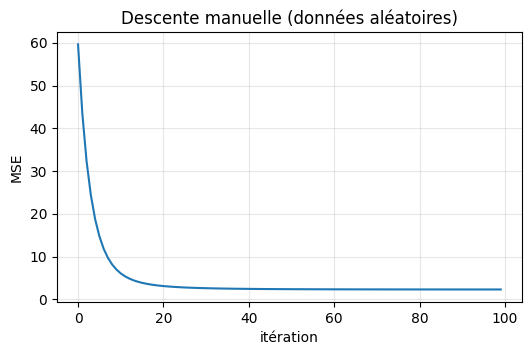

In [5]:
from torch.utils.tensorboard import SummaryWriter

torch.manual_seed(0)

# Les données supervisées : b = 50 individus, p = 13 features, d = 3 sorties
x = torch.randn(50, 13)
y = torch.randn(50, 3)

# Les paramètres du modèle à optimiser
w = torch.randn(13, 3)      # (p, d)
beta = torch.randn(3)       # (d,)

epsilon = 0.05

writer = SummaryWriter("runs/descente_manuelle")
losses_manual = []
for n_iter in range(100):
    ##  Calcul du forward (loss)
    ctx_lin, ctx_mse = Context(), Context()
    yhat = Linear.forward(ctx_lin, x, w, beta)
    loss = MSE.forward(ctx_mse, yhat, y)

    # `loss` doit correspondre au coût MSE calculé à cette itération
    writer.add_scalar('Loss/train', loss, n_iter)
    losses_manual.append(loss.item())
    if n_iter % 10 == 0 or n_iter == 99:
        print(f"Itérations {n_iter}: loss {loss:.4f}")

    ##  Calcul du backward (grad_w, grad_beta)
    grad_yhat, _ = MSE.backward(ctx_mse, torch.tensor(1.)) # on met 1 pour L 
    _, grad_w, grad_beta = Linear.backward(ctx_lin, grad_yhat)

    ##  Mise à jour des paramètres du modèle
    w = w - epsilon * grad_w
    beta = beta - epsilon * grad_beta
writer.close()

plt.figure(figsize=(6, 3.5))
plt.plot(losses_manual)
plt.xlabel("itération"); plt.ylabel("MSE"); plt.title("Descente manuelle (données aléatoires)")
plt.grid(alpha=.3); plt.show()

Les cibles $\mathbf{y}$ étant du bruit indépendant de $\mathbf{x}$, la loss ne tend pas vers 0 mais vers l'erreur résiduelle des moindres carrés.

### Question 7.1 & 7.2 — Descente batch avec autograd sur *California Housing*

- Données : 20 640 exemples, 8 features, cible = prix médian (en 100 k$).
- Découpage 80 % train / 20 % test ; les features sont **standardisées** avec les statistiques du train (sans cela, les features ont des échelles très différentes et la descente diverge ou est très lente).
- Les paramètres ont `requires_grad=True` ; `loss.backward()` remplit `W.grad` et `b.grad`. Nos `Function` (`linear`, `mse`) s'intègrent directement dans le graphe d'autograd via `.apply`.
- La mise à jour se fait sous `torch.no_grad()` et on remet les gradients à zéro (sinon ils s'accumulent).

In [6]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

data = fetch_california_housing()
X_np, y_np = data.data, data.target.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = (torch.tensor(a, dtype=torch.float32) for a in (X_train, X_test, y_train, y_test))

mean, std = X_train.mean(0), X_train.std(0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

n_features = X_train.shape[1]
print("train :", tuple(X_train.shape), " test :", tuple(X_test.shape))
print("features :", data.feature_names)

train : (16512, 8)  test : (4128, 8)
features : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


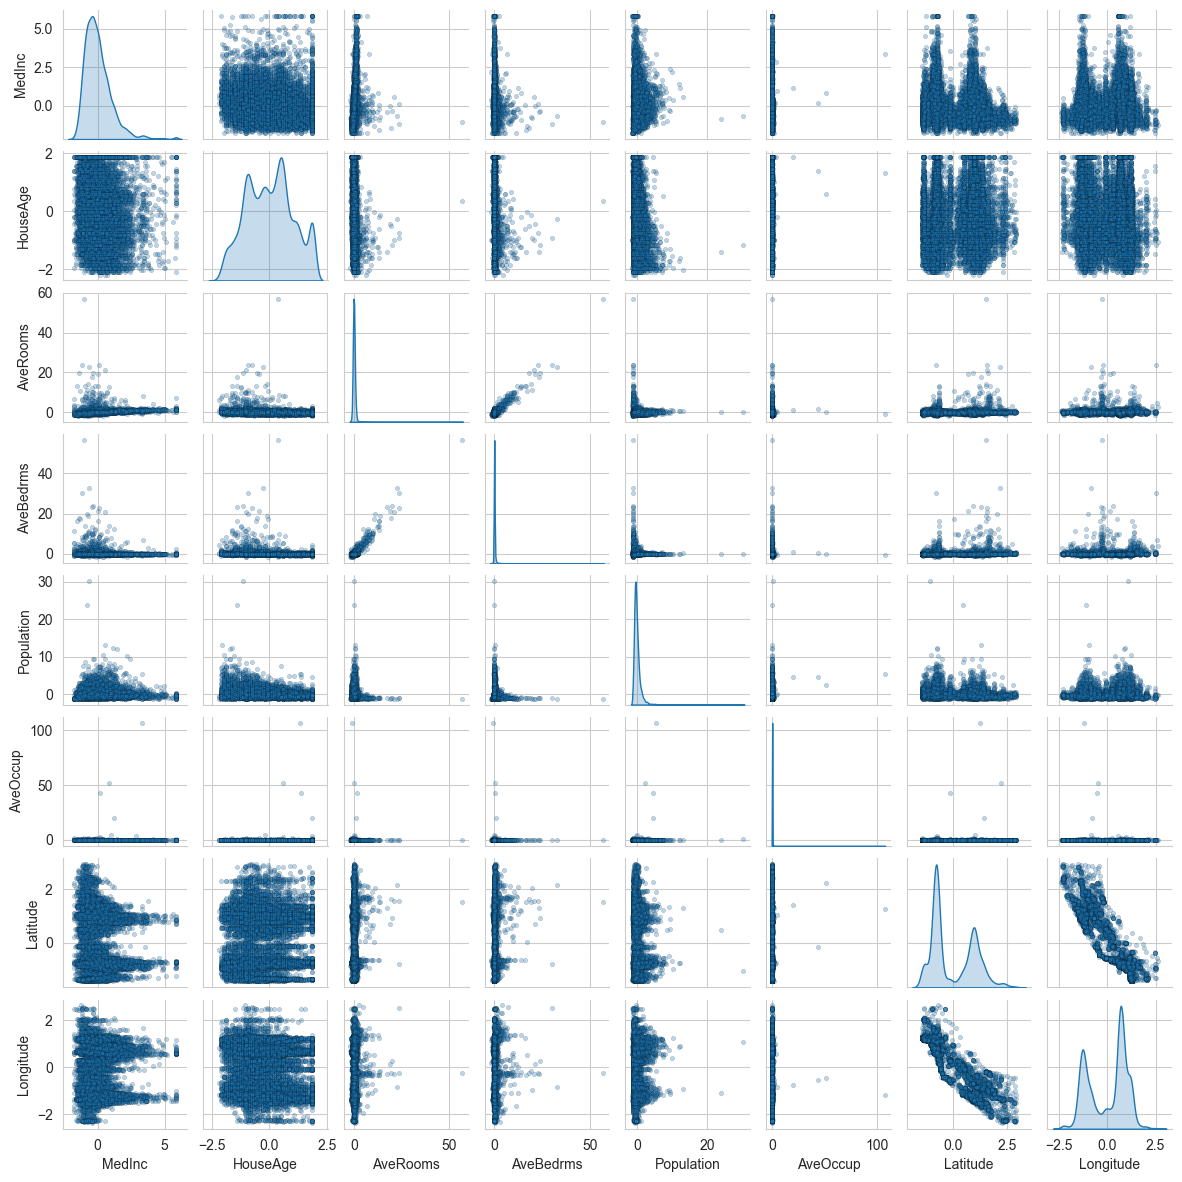

In [7]:
sns.set_style("whitegrid")
sns.pairplot(
    data=pd.DataFrame(X_train.numpy(), columns=data.feature_names),
    diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10, "edgecolor": "k"},
    height=1.5
);

In [8]:
print("Shape of X_train:", X_train.shape)   
print("Shape of y_train:", y_train.shape) 

# on ajoute une colonne de 1 pour le biais, SANS écraser X_train
Xa = torch.cat([X_train, torch.ones(X_train.shape[0], 1)], dim=1)
print("Shape de Xa:", Xa.shape)          


# erreur ! 
#theta = torch.linalg.inv(Xa.T @ Xa) @ Xa.T @ y_train
#print("Shape of W:", W.shape)

# équations normales : (XaᵀXa) θ = Xaᵀ y  -> on résout le système
theta = torch.linalg.solve(Xa.T @ Xa, Xa.T @ y_train)
print("Shape of theta:", theta.shape)    

Y_pred = Xa @ theta
mse_train = ((Y_pred - y_train) ** 2).mean()  
print("MSE on training set:", mse_train.item()) 

Shape of X_train: torch.Size([16512, 8])
Shape of y_train: torch.Size([16512, 1])
Shape de Xa: torch.Size([16512, 9])
Shape of theta: torch.Size([9, 1])
MSE on training set: 0.5179330706596375


Référence : solution exacte des moindres carrés (équations normales), pour savoir vers quelle loss on doit converger.

In [9]:
Xa = torch.cat([X_train, torch.ones(len(X_train), 1)], 1).double()
theta = torch.linalg.lstsq(Xa, y_train.double()).solution.float()
W_opt, b_opt = theta[:-1], theta[-1]
train_opt = ((X_train @ W_opt + b_opt - y_train) ** 2).mean().item()
test_opt = ((X_test @ W_opt + b_opt - y_test) ** 2).mean().item()
print(f"Moindres carrés exacts : MSE train = {train_opt:.4f} | MSE test = {test_opt:.4f}")

Moindres carrés exacts : MSE train = 0.5179 | MSE test = 0.5559


In [10]:
def train(batch_size, lr, n_epochs, name, seed=0):
    """Descente de gradient avec autograd.

    batch_size = None -> batch complet (b = n) ; 1 -> stochastique ; k -> mini-batch (b = k).
    Retourne l'historique (par époque) des loss train/test, du nombre de mises à jour et du temps.
    """
    torch.manual_seed(seed)
    n, p = X_train.shape        # n individus, p features
    d = 1                       # une seule sortie : le prix
    W = (0.01 * torch.randn(p, d)).requires_grad_()     # (p, 1)
    beta = torch.zeros(d, requires_grad=True)           # (1,)

    b = n if batch_size is None else batch_size
    writer = SummaryWriter(f"runs/california/{name}")
    hist = {"train": [], "test": [], "updates": [], "time": []}
    n_updates, t0 = 0, time.perf_counter()

    def evaluate(epoch):
        with torch.no_grad():
            tr = mse(linear(X_train, W, beta), y_train).item()
            te = mse(linear(X_test, W, beta), y_test).item()
        writer.add_scalar("Loss/train", tr, epoch)
        writer.add_scalar("Loss/test", te, epoch)
        hist["train"].append(tr); hist["test"].append(te)
        hist["updates"].append(n_updates); hist["time"].append(time.perf_counter() - t0)

    evaluate(0)
    for epoch in range(1, n_epochs + 1):
        perm = torch.randperm(n)
        for i in range(0, n, b):
            idx = perm[i:i + b]                                  # un batch de b individus
            loss = mse(linear(X_train[idx], W, beta), y_train[idx])
            loss.backward()
            with torch.no_grad():
                W -= lr * W.grad
                beta -= lr * beta.grad
                W.grad.zero_()
                beta.grad.zero_()
            n_updates += 1
        evaluate(epoch)
    writer.close()
    print(f"{name:>12} | {n_epochs:4d} époques | {n_updates:7d} maj | {hist['time'][-1]:6.1f}s "
          f"| train {hist['train'][-1]:.4f} | test {hist['test'][-1]:.4f}")
    return hist

       batch | 1000 époques |    1000 maj |    0.4s | train 0.5179 | test 0.5559


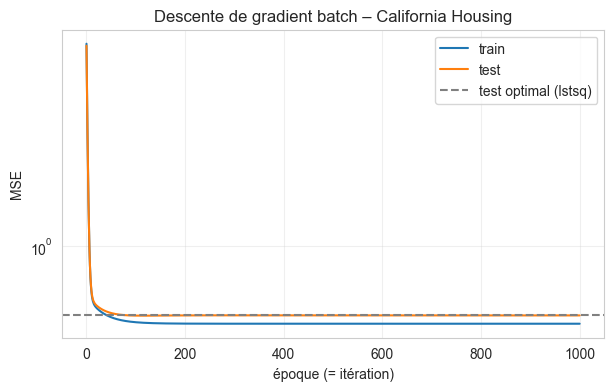

In [11]:
hist_batch = train(batch_size=None, lr=0.1, n_epochs=1000, name="batch")

plt.figure(figsize=(7, 4))
plt.plot(hist_batch["train"], label="train")
plt.plot(hist_batch["test"], label="test")
plt.axhline(test_opt, ls="--", c="gray", label="test optimal (lstsq)")
plt.yscale("log"); plt.xlabel("époque (= itération)"); plt.ylabel("MSE")
plt.title("Descente de gradient batch – California Housing")
plt.legend(); plt.grid(alpha=.3); plt.show()

Les courbes train et test décroissent ensemble et se stabilisent autour de la solution des moindres carrés : le modèle linéaire (9 paramètres) est trop simple pour sur‑apprendre ; l'erreur restante (~0.55, soit ~74 k\$ d'écart‑type) est un **biais** du modèle linéaire. Les courbes sont aussi visibles dans TensorBoard (`runs/california/`).

### Question 7.4 — Stochastique vs mini‑batch vs batch

- **Batch** : 1 mise à jour par époque, gradient exact.
- **Mini‑batch** (32 exemples) : ~516 mises à jour par époque.
- **Stochastique** (1 exemple) : 16 512 mises à jour par époque, gradient très bruité → pas d'apprentissage beaucoup plus petit.

**Choix du pas pour le SGD.** Pour un seul exemple, la mise à jour est stable seulement si $\epsilon < 1/\|\mathbf{x}\|^2$ (la hessienne de $(\mathbf{x}\cdot\mathbf{w}+b-y)^2$ vaut $2\mathbf{x}\mathbf{x}^\top$). Or California Housing contient des valeurs aberrantes (`AveOccup`, `AveRooms`… à plus de 50 écarts‑types) : certains exemples ont $\|\mathbf{x}\|^2 \approx 11\,500$. Avec $\epsilon = 10^{-3}$ le SGD **diverge** dès qu'il tombe sur l'un d'eux ; il faut $\epsilon \lesssim 9\cdot 10^{-5}$. Le mini‑batch moyenne ces exemples avec 31 autres et tolère un pas 200 fois plus grand.

In [12]:
norms = (X_train ** 2).sum(1)
print(f"||x||^2 : médiane {norms.median():.1f} | 99e centile {norms.quantile(.99):.1f} | max {norms.max():.0f}")
print(f"=> pas max stable pour le SGD ~ 1/max = {1 / norms.max():.1e}")

||x||^2 : médiane 4.1 | 99e centile 38.9 | max 11518
=> pas max stable pour le SGD ~ 1/max = 8.7e-05


In [13]:
hist_mini = train(batch_size=32, lr=0.01, n_epochs=30, name="minibatch_32")
hist_sgd = train(batch_size=1, lr=5e-5, n_epochs=10, name="sgd")

minibatch_32 |   30 époques |   15480 maj |    0.9s | train 0.5485 | test 0.5548
         sgd |   10 époques |  165120 maj |    8.4s | train 0.5299 | test 0.5645


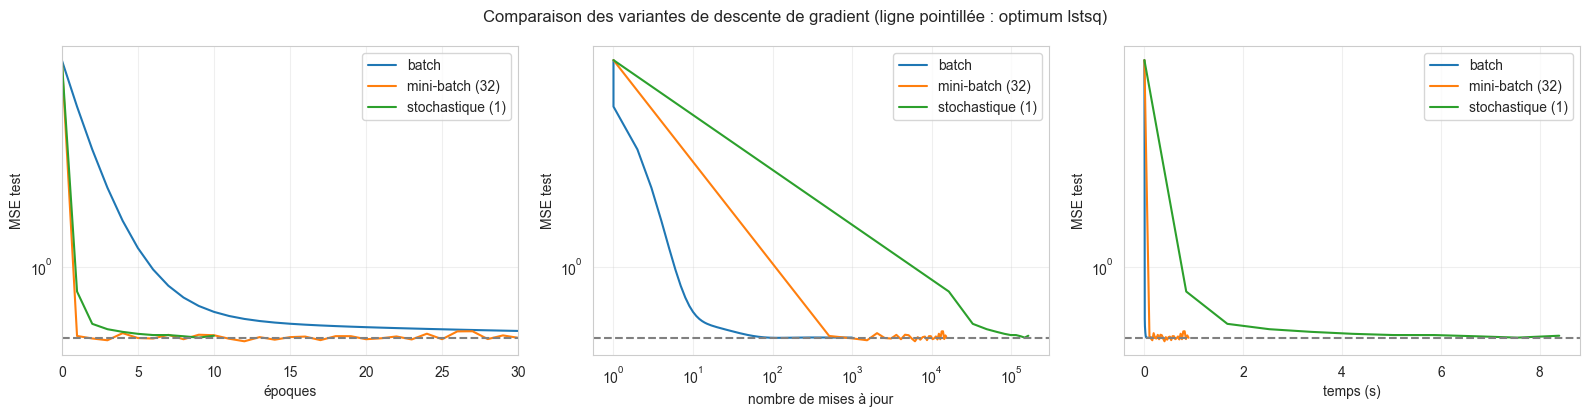

In [14]:
runs = {"batch": hist_batch, "mini-batch (32)": hist_mini, "stochastique (1)": hist_sgd}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for label, h in runs.items():
    axes[0].plot(range(len(h["test"])), h["test"], label=label)
    axes[1].plot([max(u, 1) for u in h["updates"]], h["test"], label=label)
    axes[2].plot(h["time"], h["test"], label=label)
axes[0].set_xlabel("époques"); axes[0].set_xlim(0, 30)
axes[1].set_xlabel("nombre de mises à jour"); axes[1].set_xscale("log")
axes[2].set_xlabel("temps (s)")
for ax in axes:
    ax.axhline(test_opt, ls="--", c="gray")
    ax.set_yscale("log"); ax.set_ylabel("MSE test"); ax.grid(alpha=.3); ax.legend()
fig.suptitle("Comparaison des variantes de descente de gradient (ligne pointillée : optimum lstsq)")
plt.tight_layout(); plt.show()

In [15]:
print(f"{'méthode':>18} | {'MSE train':>9} | {'MSE test':>8} | {'maj':>7} | {'temps':>6}")
for label, h in runs.items():
    print(f"{label:>18} | {h['train'][-1]:9.4f} | {h['test'][-1]:8.4f} | {h['updates'][-1]:7d} | {h['time'][-1]:5.1f}s")
print(f"{'lstsq (optimum)':>18} | {train_opt:9.4f} | {test_opt:8.4f} |")

           méthode | MSE train | MSE test |     maj |  temps
             batch |    0.5179 |   0.5559 |    1000 |   0.4s
   mini-batch (32) |    0.5485 |   0.5548 |   15480 |   0.9s
  stochastique (1) |    0.5299 |   0.5645 |  165120 |   8.4s
   lstsq (optimum) |    0.5179 |   0.5559 |


**Analyse** (chiffres mesurés ci‑dessus)

- **Par époque** (même nombre d'exemples vus) : le mini‑batch passe sous 0.57 de MSE test dès la **1ʳᵉ époque**, le SGD en ~6 époques (son pas est bridé par les exemples aberrants), alors que le batch a besoin de ~50 époques, puis de plusieurs centaines pour atteindre exactement l'optimum : il ne fait qu'une mise à jour par époque.
- **Par mise à jour** : le batch est de loin le plus efficace (gradient exact, grand pas $\epsilon=0.1$) ; le SGD le moins (gradient très bruité, pas minuscule).
- **En temps** : sur ce petit problème (16 512 × 8, CPU), le **batch est le plus rapide** : une époque = un seul produit matriciel vectorisé, donc 1000 époques coûtent < 1 s. Le mini‑batch est du même ordre (quelques centièmes de seconde pour une bonne solution). Le SGD est ~100× plus lent : chaque mise à jour paie le surcoût Python/autograd pour un seul exemple, sans aucun parallélisme.
- **Qualité finale** : le batch converge exactement vers la solution des moindres carrés. Le mini‑batch et le SGD à pas constant **oscillent** autour de l'optimum (train 0.53–0.55 au lieu de 0.518, test qui fluctue de ±0.01 d'une époque à l'autre) à cause de la variance du gradient ; il faudrait faire décroître le pas pour converger exactement. Le SGD est en plus très sensible aux exemples aberrants, qui imposent un pas minuscule pour tout l'apprentissage (on pourrait les filtrer ou utiliser une normalisation robuste).

**Conclusion.** Ici le problème est petit et convexe, donc le batch complet est idéal. Mais son coût par pas croît avec la taille du jeu de données (et il ne tient plus en mémoire GPU pour de gros datasets / réseaux profonds), alors que le mini‑batch garde un coût par pas constant, exploite bien le parallélisme et donne une bonne solution en une fraction d'époque. C'est pour cela que le **mini‑batch** est le choix par défaut en deep learning ; le SGD pur (batch de 1) est rarement utilisé.